In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
from utils.corr import corr_by_regime, pairwise_metric, bootstrap_spearman
from utils.plots import scatterplot_finetuned # scatterplot, plot_unified_agreement_heatmap, get_family, parse_size 
from analyzer import * 
from utils.corr import human_vs_consensus 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mm = MMStarResults()
answers_pivot = mm.combine_mh(model_acc=mm.model) 

/home/work/yuna/HPA/evaluation/analysis/analyzer.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.human['correct'] = self.human['correct'] * 100


14 6
[]


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category'] = df['category'].map(mmstar_cat_map)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:177: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['question_id'] = df['question_id'].astype('Int64')


In [3]:
md = mm.model 
vlms=md[md['model_type'] != 'llm'].model.unique() 
llms=md[md['model_type'] == 'llm'].model.unique() 
all_humans = mm.human.participant_id.unique()   

In [4]:
mm.model.finetuned.unique() 

array(['Pretrained', 'JS VQA (GT)', 'SFT-Blind MMStar (n=15)',
       'JS-Blind VQA (n=10)', 'JS-Blind VQA (n=15)',
       'JS-Blind MMStar (n=15)', 'SFT-Blind VQA', 'SFT-VQA',
       'SFT-Blind MMStar'], dtype=object)

In [ ]:
hm_acc = mm.human.groupby([ 'category', 'l2_category', 'question_id'])['correct'].mean().reset_index()
alignment_results = []
n_boot = 1000

for vlm in md.model.unique() : 
    hm = pd.merge(hm_acc, md[md['model'] == vlm], 
                    on=['category', 'l2_category', 'question_id'], 
                    how='inner',
                    suffixes=("_human", '_model'))  
    for ft in hm.finetuned.unique(): 
        theta_hat = pairwise_metric(hm[hm['finetuned']==ft]['correct_model'].values, hm[hm['finetuned']==ft]['correct_human'].values)  
        
        if n_boot: 
            boot =  bootstrap_spearman(hm[hm['finetuned']==ft]['correct_model'].values, hm[hm['finetuned']==ft]['correct_human'].values, n_boot, 42) 
            ci = np.percentile(boot, [2.5, 97.5]) # 95% percentile CI

        alignment_results.append({
            'model': vlm, 
            'theta_hat': theta_hat, 
            "ci": ci,
            "finetuned": ft, 
            # 'data': hm 
        }) 
df = pd.DataFrame(alignment_results)

human_correct =mm.human.pivot( index=['participant_id'], columns=['question_id'], values=['correct']).to_numpy()
human_correct = (human_correct > 0).astype(int)
human_rhos = human_vs_consensus(human_correct) 
low, high = np.percentile(human_rhos, [2.5, 97.5])
mu = human_rhos.mean()
sd = human_rhos.std()
human_correct.shape , mu,sd 

((20, 247), 0.290796260316054, 0.09906076795651508)

In [9]:
df.to_json('./correlations/mmstar_pretrained.json')

In [ ]:
df = pd.read_json('./correlations/mmstar_pretrained.json')

In [ ]:
df = df[df['finetuned'] == 'Pretrained']
models = df.model.values # list(alignment_results.keys())
rhos = df.theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])
ci_lows = np.array([c[0] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
ci_highs = np.array([c[1] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])

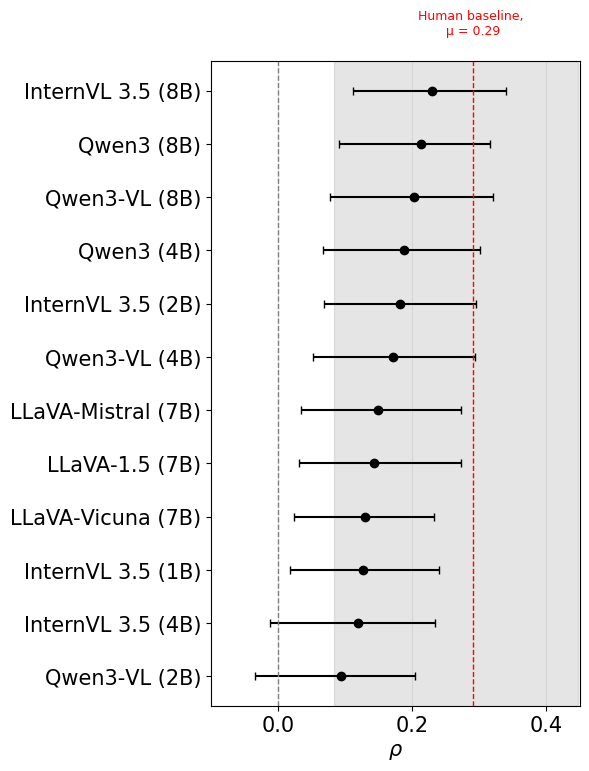

In [11]:
order = np.argsort(rhos)
models = [models[i] for i in order]
rhos = rhos[order]
ci_lows = ci_lows[order]
ci_highs = ci_highs[order]
y = np.arange(len(models))

plt.figure(figsize=(6, 3 + 0.4 * len(models)))
plt.errorbar(
    rhos,
    y,
    xerr=[rhos - ci_lows, ci_highs - rhos],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=1.5,
    capsize=3,
)

plt.yticks(y, models)
plt.xlabel(r"$\rho$") # Spearman correlation to human consensus 
# plt.title("Model–Human Alignment")
plt.axvspan(
    low,
    high,
    color="gray",
    alpha=0.2,
    label="Human baseline (95%)"
)

plt.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=1
)
plt.text(
    mu,
    len(models),
    f"Human baseline, \nμ = {mu:.2f}",
    ha="center",
    va="bottom",
    fontsize=9,
    color="red"
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.xlim(-0.1, 0.45)   # or tighter: (0.0, 0.4)
plt.tight_layout()
plt.show()

## VQA 

In [ ]:
vv = VQAResults()   
human_vqa = vv.human.drop_duplicates(subset=['question_id', 'participant_id']) 
# get_agreements(human_vqa, model_vqa, metrics="correct", n_boot=200) 
model_vqa = vv.model  # only the blind condition 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
before 38.98698056001426
after  39.8876404494382
14 6
[]
before 56.376171604938264
after  56.553126337448575
[]
before 56.50236445408408
after  56.66504286986308


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:400: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)


processed_ans                                 1
correct                                   100.0
gt_answers       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Name: 6424, dtype: object

In [ ]:
# hm_sim = mm.human.groupby(['question_id'])[''].mean().values
hm_acc = human_vqa.groupby(['answer_type', 'question_type', 'question_id'])[['correct', 'answer_similarity']].mean().reset_index()
alignment_results = []
n_boot = 1000 

for metric in ['answer_similarity', 'correct']: 
    for vlm in model_vqa.model.unique() : 
        hm = pd.merge(hm_acc, model_vqa[model_vqa['model'] == vlm], 
                        on=['answer_type', 'question_type', 'question_id'], 
                        how='inner',
                        suffixes=("_human", '_model'))  
            
        for ft in model_vqa.finetuned.unique(): 
            theta_hat = pairwise_metric(hm[hm['finetuned']==ft][f'{metric}_model'].values, 
                                        hm[hm['finetuned']==ft][f'{metric}_human'].values)  
            if n_boot: 
                boot =  bootstrap_spearman(hm[hm['finetuned']==ft][f'{metric}_model'].values, 
                                            hm[hm['finetuned']==ft][f'{metric}_human'].values, n_boot, 42) 
                ci = np.percentile(boot, [2.5, 97.5]) # 95% percentile CI 

            alignment_results.append({ 
                'model': vlm, 
                'theta_hat': theta_hat, 
                "ci": ci, 
                'metric': metric , 
                'finetuned': ft
                # 'data': hm 
            }) 
df = pd.DataFrame(alignment_results)

In [ ]:
df.to_json('./correlations/vqa_pretrained.json')  

In [12]:
df = pd.read_json('./correlations/vqa.json') 

In [18]:
human_correct = human_vqa.pivot( index=['participant_id'], columns=['question_id'], values=['correct']).to_numpy()
human_correct = (human_correct > 0).astype(int)
human_rhos = human_vs_consensus(human_correct) 
low, high = np.percentile(human_rhos, [2.5, 97.5]) 
mu, sd = human_rhos.mean(), human_rhos.std() 

In [26]:
pretrained_corr = df[df['finetuned'] == "Pretrained"] 
models = pretrained_corr.model.values # list(alignment_results.keys())

def get_model_corr(df=pretrained_corr): 
    rhos_acc = df[df['metric'] == 'correct'].theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])
    ci_lows_acc = np.array([c[0] for c in df[df['metric'] == 'correct'].ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
    ci_highs_acc = np.array([c[1] for c in df[df['metric'] == 'correct'].ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])

    rhos_sim = df[df['metric'] == 'answer_similarity'].theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])
    ci_lows_sim = np.array([c[0] for c in df[df['metric'] == 'answer_similarity'].ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
    ci_highs_sim = np.array([c[1] for c in df[df['metric'] == 'answer_similarity'].ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])
    return rhos_acc, ci_lows_acc, ci_highs_acc, rhos_sim, ci_lows_sim, ci_highs_sim

rhos_acc, ci_lows_acc, ci_highs_acc, rhos_sim, ci_lows_sim, ci_highs_sim = get_model_corr() 
np.mean(rhos_sim), np.std(rhos_sim), np.min(rhos_sim), np.max(rhos_sim)
np.mean(rhos_acc), np.std(rhos_acc), np.min(rhos_acc), np.max(rhos_acc) 

(0.5907329545153639,
 0.07091014600556007,
 0.48903708088016484,
 0.6791713235747031)

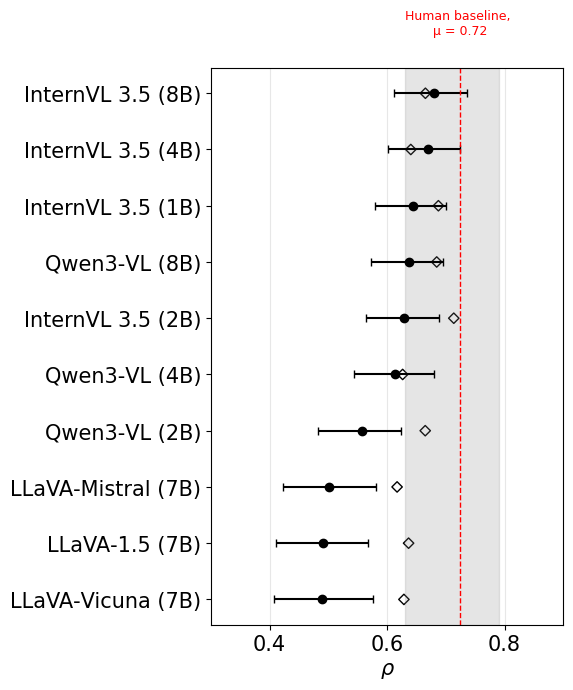

In [28]:
order = np.argsort(rhos_acc)
models = [models[i] for i in order]
rhos_acc = rhos_acc[order]
ci_lows_acc = ci_lows_acc[order]
ci_highs_acc = ci_highs_acc[order]

rhos_sim = rhos_sim[order] 
ci_lows_sim = ci_lows_sim[order] 
ci_highs_sim = ci_highs_sim[order] 

y = np.arange(len(models))

plt.figure(figsize=(6, 3 + 0.4 * len(models)))
plt.errorbar(
    rhos_acc,
    y,
    xerr=[rhos_acc - ci_lows_acc, ci_highs_acc - rhos_acc],
    fmt="o",
    color="black",
    capsize=3,
    label="Correctness"
)
offset = 0.015  # small horizontal separation
plt.scatter(
    rhos_sim + offset,
    y,
    marker="D",
    s=28,
    facecolors="none",
    edgecolors="black",
    linewidths=1,
    label="Answer similarity"
)
plt.yticks(y, models)
plt.xlabel(r"$\rho$") # Spearman correlation to human consensus 
# plt.title("Model–Human Alignment")
plt.axvspan(
    low,
    high,
    color="gray",
    alpha=0.2,
    label="Human baseline (95%)"
)

plt.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=1
)
plt.text(
    mu,
    len(models),
    f"Human baseline, \nμ = {mu:.2f}",
    ha="center",
    va="bottom",
    fontsize=9,
    color="red"
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.xlim(0.3, 0.9)   # or tighter: (0.0, 0.4)
plt.tight_layout()
plt.show()

## MG Scatterplots 

In [ ]:
pcorr.finetuned.unique() 

array(['Pretrained', 'JS VQA (GT)', 'JS-Blind VQA (n=10)',
       'JS-Blind VQA (n=15)', 'JS-Blind MMStar (n=15)', 'SFT-Blind VQA',
       'SFT-VQA', 'SFT-Blind MMStar'], dtype=object)

In [33]:
sim_mg = vv.test_model_mg_sim.groupby(['model', 'finetuned'])['MG'].mean().reset_index()
acc_mg = vv.test_model_mg_acc.groupby(['model', 'finetuned'])['MG'].mean().reset_index() # .dropna(axis=1).groupby(['model', 'finetuned']).mean(numeric_only=True)
vqa_mg = pd.merge(sim_mg, acc_mg, suffixes=('_sim', '_acc'), how='inner', on=['model', 'finetuned'])
vqa_mg['family'] = vqa_mg['model'].map(get_family)
vqa_mg['model_size'] = vqa_mg['model'].map(parse_size)      

finetuned_list = ['Pretrained', 'JS VQA (GT)', 'JS-Blind VQA (n=15)', 'SFT-Blind VQA',  'SFT-VQA'] 
pcorr = pd.merge(df[df['metric'] == 'correct'], vqa_mg, on=['model', 'finetuned']) 
pcorr = pcorr[pcorr['finetuned'].isin(finetuned_list)] # ,'JS-Blind VQA (n=10)', 'SFT-Blind MMStar', 'JS-Blind MMStar (n=15)',  

sim_corr = pd.merge(df[df['metric'] == 'answer_similarity'], vqa_mg, on=['model', 'finetuned']) 
sim_corr = sim_corr[sim_corr['finetuned'].isin(finetuned_list)] # ,'JS-Blind VQA (n=10)', 'SFT-Blind MMStar', 'JS-Blind MMStar (n=15)',  
sim_corr

,model,theta_hat,ci,metric,finetuned,MG_sim,MG_acc,family,model_size
0,InternVL 3.5 (1B),0.672304,"[0.5979492017663565, 0.7381143770327844]",answer_similarity,Pretrained,18.13546,38.340560,InternVL,1.0
1,InternVL 3.5 (2B),0.698453,"[0.6277074597738694, 0.7579556169859833]",answer_similarity,Pretrained,19.62734,41.107293,InternVL,2.0
2,InternVL 3.5 (4B),0.625306,"[0.542412475191158, 0.6930552921551807]",answer_similarity,Pretrained,23.28442,39.660587,InternVL,4.0
3,InternVL 3.5 (8B),0.650164,"[0.5700057377744644, 0.7200595701619095]",answer_similarity,Pretrained,22.03780,42.974167,InternVL,8.0
4,InternVL 3.5 (8B),0.586976,"[0.5027579311923421, 0.662722067825244]",answer_similarity,JS VQA (GT),18.53628,40.554287,InternVL,8.0
6,InternVL 3.5 (8B),0.686916,"[0.6143192785168502, 0.7486814475448382]",answer_similarity,JS-Blind VQA (n=15),17.86950,39.800953,InternVL,8.0
8,InternVL 3.5 (8B),0.684410,"[0.6108676224316728, 0.7530661670223259]",answer_similarity,SFT-Blind VQA,17.88102,39.987653,InternVL,8.0
9,InternVL 3.5 (8B),0.540160,"[0.44610494570254916, 0.6214062622103482]",answer_similarity,SFT-VQA,18.44638,40.147520,InternVL,8.0
10,Qwen3‑VL (2B),0.649871,"[0.5686184730827905, 0.7136935399607571]",answer_similarity,Pretrained,20.72508,42.120360,Qwen,2.0
11,Qwen3‑VL (4B),0.611424,"[0.5260613421244446, 0.6856785717705213]",answer_similarity,Pretrained,22.05018,45.074000,Qwen,4.0


In [157]:
import matplotlib.pyplot as plt
import seaborn as sns


JS_REGIMES  = ["JS VQA (GT)", "JS-Blind VQA (n=15)"]
SFT_REGIMES = ["SFT-Blind VQA", "SFT-VQA"] 

REGIME_GROUPS = {
    "JS":  JS_REGIMES,
    "SFT": SFT_REGIMES,
}
regime_colors  = {
    # Ground‑truth supervised (blue family)
    "JS VQA (GT)":  "#4C72B0",  # darker muted blue
    "SFT-VQA":      "#8DA0CB",  # lighter blue

    # Blind training (gray family)
    "JS-Blind VQA (n=15)": "#7F7F7F",  # darker gray
    "SFT-Blind VQA":       "#B0B0B0",  # lighter gray
}
REGIME_LINESTYLE = {'JS': {'color': '#4C72B0', 'linestyle': '--'},
                    'SFT': {'color': "gray", 'linestyle': '--'}}  # '#DD8452' 
family_markers = {
    'InternVL': 'o', 
    'LLaVA': 's', 
    'Qwen': '^',
    'BLIP': '^',  
}
family_colors = {
    "InternVL": "#4C72B0",        # muted blue
    "LLaVA":    "#DD8452",        # muted orange
    "Qwen":     "#55A868",        # muted green
    "BLIP":     "#C44E52",        # muted red
}

regime_markers = {
    'Pretrained': 'o', 
    'JS VQA (GT)': 's', 
    'SFT-VQA': 's',
    'JS-Blind VQA (n=15)': '^',  
    'SFT-Blind VQA': '^', 
}

def get_delta_df(df): 
    delta_rows = []

    for fam in df["family"].unique():
        fam_data = df[df["family"] == fam]

        for _, fin in fam_data[fam_data["finetuned"] != "Pretrained"].iterrows():
            pre = fam_data[
                (fam_data["model"] == fin["model"]) &
                (fam_data["finetuned"] == "Pretrained")
            ]
            if pre.empty:
                continue

            pre = pre.iloc[0]

            delta_rows.append({
                "family": fam,
                "model": fin["model"],
                "finetuned": fin["finetuned"],
                "delta_theta": fin["theta_hat"] - pre["theta_hat"],
                "delta_mg": fin["MG_acc"] - pre["MG_acc"],
                "model_size": fin["model_size"],
            })

    delta_df = pd.DataFrame(delta_rows)
    size_vals = delta_df["model_size"].astype(float)
    size_norm = (size_vals - size_vals.min()) / (size_vals.max() - size_vals.min() + 1e-6)
    delta_df["_size_norm"] = 0.5 + size_norm
    return delta_df 

def scatterplot_delta_alignment_vs_mg(
    delta_df,
    title,
    colors,          # keyed by finetuned regime
    markers,         # keyed by family (or regime if you prefer)
    size_col="model_size",
    size_scale=500,
    figsize=(12, 7),
):
    fig, ax = plt.subplots(figsize=figsize)
    # --------------------------------------------------
    # Regression per regime group
    # --------------------------------------------------
    for regime, labels in REGIME_GROUPS.items():
        data = delta_df[delta_df["finetuned"].isin(labels)]
        if len(data) < 3:
            continue

        sns.regplot(
            data=data,
            x="delta_theta",
            y="delta_mg",
            scatter=False,
            ci=None,
            ax=ax,
            line_kws=dict(
                linewidth=2.0,
                alpha=0.9,
                zorder=2,
                **REGIME_LINESTYLE[regime],
            ),
        )
    for regime, stats_ in regression_stats.items():
        slope = stats_["slope"]
        intercept = stats_["intercept"]
        r_val = stats_["r"]

        eq_text = (
            rf"$\Delta$MG $= {slope:.2f}\,\Delta\hat{{\theta}} {intercept:+.2f}$" "\n"
            rf"$r = {r_val:.2f}$"
        )

        ax.text(
            EQ_POS[regime][0],
            EQ_POS[regime][1],
            eq_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
            color=REGIME_LINESTYLE[regime]["color"],
            # alpha=0.9,
        )
    # --------------------------------------------------
    # Scatter points
    # --------------------------------------------------
    used_regime_labels = set()

    for _, row in delta_df.iterrows():
        reg = row["finetuned"]
        fam = row["family"]

        show_regime = reg not in used_regime_labels

        ax.scatter(
            row["delta_theta"],
            row["delta_mg"],
            s=row["_size_norm"] * size_scale,
            color=colors[reg],
            marker=markers[fam],
            alpha=0.75,
            edgecolors="white",
            linewidth=0.4,
            zorder=3,
            label=reg if show_regime else None,
        )

        if show_regime:
            used_regime_labels.add(reg)
    ax.axhline(0, color="black", lw=1.1, alpha=0.7)
    ax.axvline(0, color="black", lw=1.1, alpha=0.7)

    # --------------------------------------------------
    # Labels, title, legend
    # --------------------------------------------------
    ax.set_xlabel(r"$\Delta\ \hat{\theta}$ (alignment change)", fontsize=11)
    ax.set_ylabel(r"$\Delta$ MG accuracy", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(
        True,
        which="major",
        linewidth=0.5,
        alpha=0.2,
    )
    ax.set_axisbelow(True)
    handles, labels = ax.get_legend_handles_labels()
    desired_order = ['JS VQA (GT)', 'SFT-VQA', 'JS-Blind VQA (n=15)', 'SFT-Blind VQA']
    order = [labels.index(reg) for reg in desired_order if reg in labels]
    ordered_handles = [handles[idx] for idx in order]
    ordered_labels = [labels[idx] for idx in order]

    ax.legend(
        ordered_handles,
        ordered_labels,
        title="Training regime",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.2),  # position legend above plot
        frameon=True,
        # fancybox=True,
        # framealpha=0.9,
        # edgecolor="black",
        fontsize=9,
        title_fontsize=9,
        markerscale=0.8,
        ncol=4,
    )
    plt.tight_layout()
    plt.show()

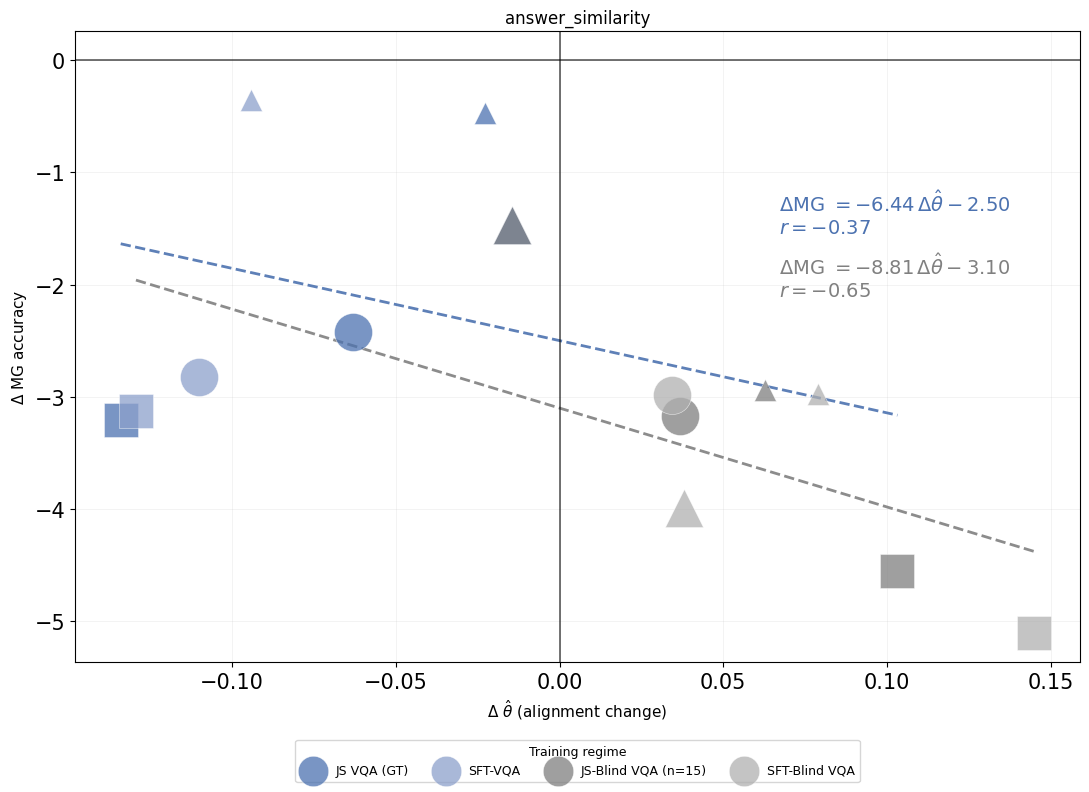

In [160]:
from scipy import stats

x_col = "theta_hat"
y_col = "MG_sim" 
delta_df = get_delta_df(sim_corr)
regression_stats = {}

EQ_POS = {
    "JS":  (0.7, 0.75),
    "SFT": (0.7, 0.65),
}
for regime, labels in REGIME_GROUPS.items():
    data = delta_df[delta_df["finetuned"].isin(labels)]
    if len(data) < 3:
        continue

    x = data["delta_theta"].to_numpy()
    y = data["delta_mg"].to_numpy()

    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    rho, _ = stats.spearmanr(x, y)

    regression_stats[regime] = {
        "slope": slope,
        "intercept": intercept,
        "r": r_val,
        "rho": rho,
    } 

scatterplot_delta_alignment_vs_mg(
    delta_df,
    title = 'answer_similarity',
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers, 
    figsize=(11,8) ) 

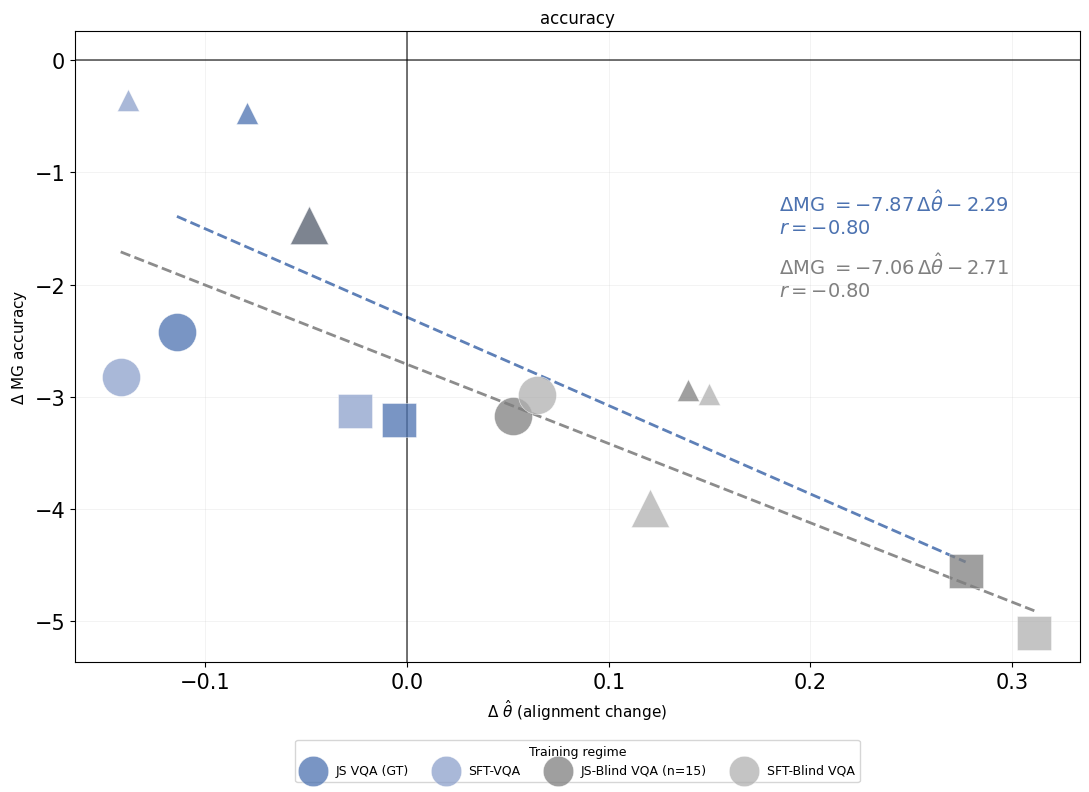

In [ ]:
from scipy import stats

x_col = "theta_hat"
y_col = "MG_acc" 
delta_df = get_delta_df(pcorr)
regression_stats = {}

EQ_POS = {
    "JS":  (0.7, 0.75),
    "SFT": (0.7, 0.65),
}
for regime, labels in REGIME_GROUPS.items():
    data = delta_df[delta_df["finetuned"].isin(labels)]
    if len(data) < 3:
        continue

    x = data["delta_theta"].to_numpy()
    y = data["delta_mg"].to_numpy()

    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    rho, _ = stats.spearmanr(x, y)

    regression_stats[regime] = {
        "slope": slope,
        "intercept": intercept,
        "r": r_val,
        "rho": rho,
    } 

scatterplot_delta_alignment_vs_mg(
    delta_df,
    title = 'accuracy',
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers ,
    figsize=(11,8) ) 

In [ ]:


scatterplot(df[df['metric'] == 'answer_similarity'], 
            x_col='sim_corr', y_col='MG_sim', title='simliarity')  

In [ ]:

if isinstance(mg_df.columns, pd.MultiIndex):
    mg_df.columns = ['_'.join(str(c) for c in col if c != '') for col in mg_df.columns.values]

### Finetuned models 

In [ ]:

pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr= pd.merge(pcorr.reset_index(), mg_df.reset_index(), on=['model'])  

pcorr = pcorr[~pcorr['model'].str.contains('|'.join(exclude_models))]
corr_by_regime(pcorr).to_latex('./tables/appendix/finetuned-pearson-r.tex', float_format="%.1f")    

for fam in pcorr.family.unique(): 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='acc_corr', y_col='MG_Acc', title=f'{fam} accuracy') # 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='sim_corr', y_col='MG_S', title=f'{fam} similairty') # 